In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 3.0 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/11.1 MB 3.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.1 MB 3.1 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/11.1 MB 3.1 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.1 MB 3.1 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.1 MB 3.1 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 2.9 MB/s eta 0:00:03
   ----------------- ---------------------- 4.7/11.1 MB 2.8 MB/s eta 0:00:03
   ------------------ --------------------- 5.2/11.1 MB 2.8 MB/s eta 0:00:03
   -------------------- ------------------- 5.8/11.1 MB 2.8 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.1 MB 2.7 MB/s eta 0:00:02
   --

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [115]:
df=pd.read_csv("C:\\Users\\Kiran\\Downloads\\healthcare_noshows_appt.csv",
               encoding="unicode-escape")

In [116]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106987 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       106987 non-null  float64
 1   AppointmentID   106987 non-null  int64  
 2   Gender          106987 non-null  object 
 3   ScheduledDay    106987 non-null  object 
 4   AppointmentDay  106987 non-null  object 
 5   Age             106987 non-null  int64  
 6   Neighbourhood   106987 non-null  object 
 7   Scholarship     106987 non-null  bool   
 8   Hipertension    106987 non-null  bool   
 9   Diabetes        106987 non-null  bool   
 10  Alcoholism      106987 non-null  bool   
 11  Handcap         106987 non-null  bool   
 12  SMS_received    106987 non-null  bool   
 13  Showed_up       106987 non-null  bool   
 14  Date.diff       106987 non-null  int64  
dtypes: bool(7), float64(1), int64(3), object(4)
memory usage: 7.2+ MB


In [97]:
df = df.drop(columns=["PatientId", "AppointmentID", "ScheduledDay","AppointmentDay"])

In [98]:
bool_cols = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'Showed_up']
df[bool_cols] = df[bool_cols].astype(int)

In [99]:
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

In [100]:
df = pd.get_dummies(df, columns=['Neighbourhood'], drop_first=True)

In [101]:
X = df.drop("Showed_up", axis=1)
y = df["Showed_up"]


In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [103]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [104]:
y_pred = model.predict(X_test)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n🧾 Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.7977381063650808

📉 Confusion Matrix:
 [[    9  4316]
 [   12 17061]]

🧾 Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.00      0.00      4325
           1       0.80      1.00      0.89     17073

    accuracy                           0.80     21398
   macro avg       0.61      0.50      0.45     21398
weighted avg       0.72      0.80      0.71     21398



C:\Users\Kiran\AppData\Roaming\Python\Python313\site-packages\sklearn\tree\_export.py:673: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
C:\Users\Kiran\AppData\Roaming\Python\Python313\site-packages\sklearn\tree\_export.py:673: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
C:\Users\Kiran\AppData\Roaming\Python\Python313\site-packages\sklearn\tree\_export.py:673: UserWarning: Glyph 137 (\x89) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
C:\Users\Kiran\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kiran\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\

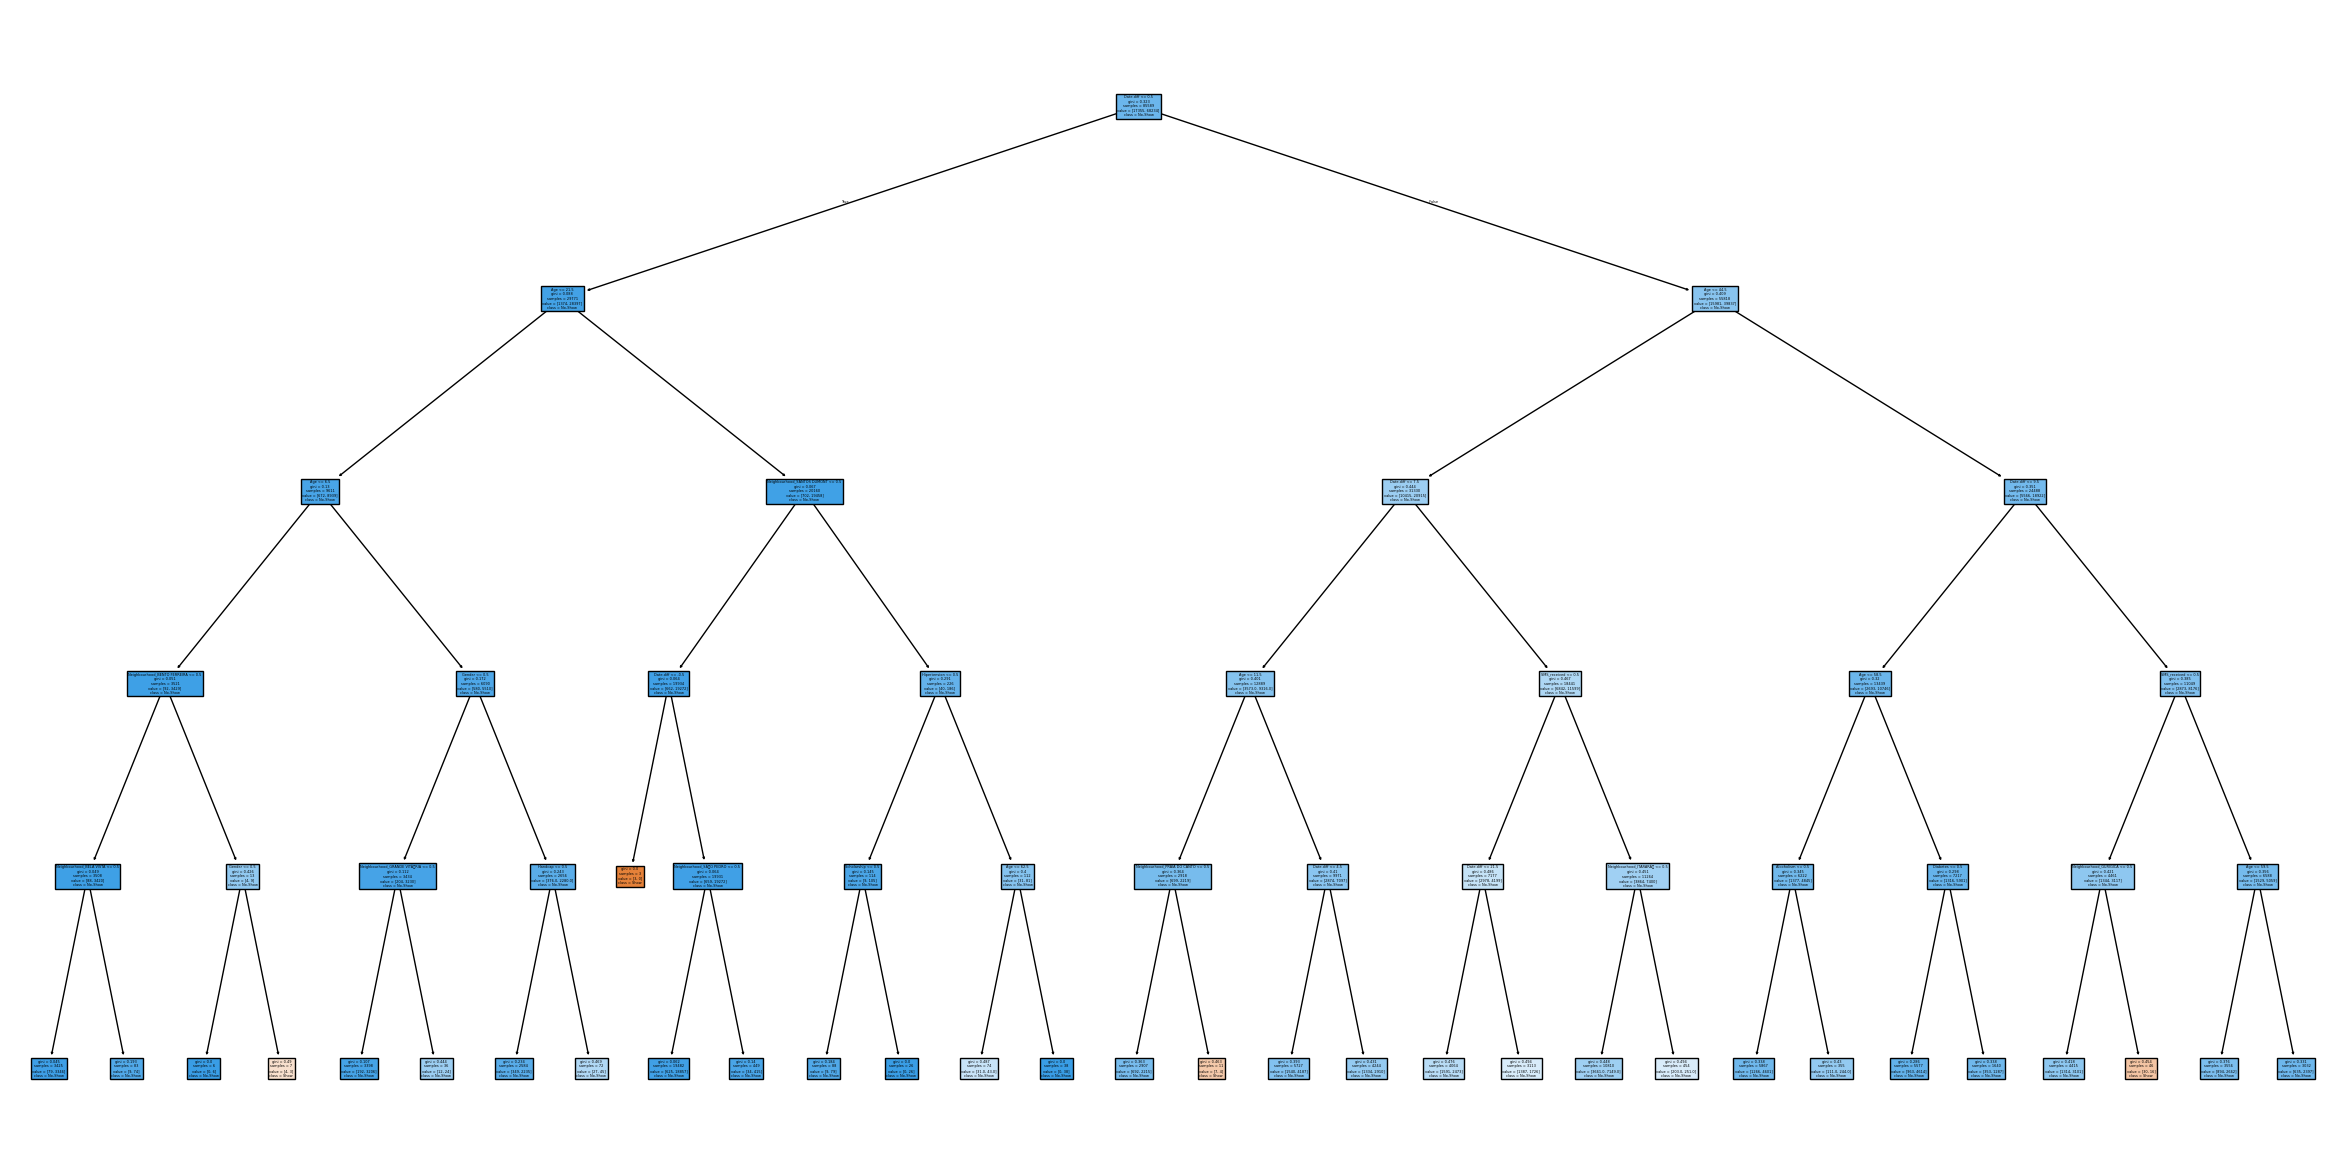

In [105]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30,15))
plot_tree(model, feature_names=X.columns, class_names=["Show", "No-Show"], filled=True)
plt.show()

In [106]:
sms_summary = df.groupby("SMS_received")["Showed_up"].agg(['count', 'sum'])
sms_summary["Show_up_Rate"] = sms_summary["sum"] / sms_summary["count"]

In [107]:
sms_summary.index = ["No SMS", "Received SMS"]

In [108]:
print(sms_summary)

              count    sum  Show_up_Rate
No SMS        72402  60290      0.832712
Received SMS  34585  25017      0.723348


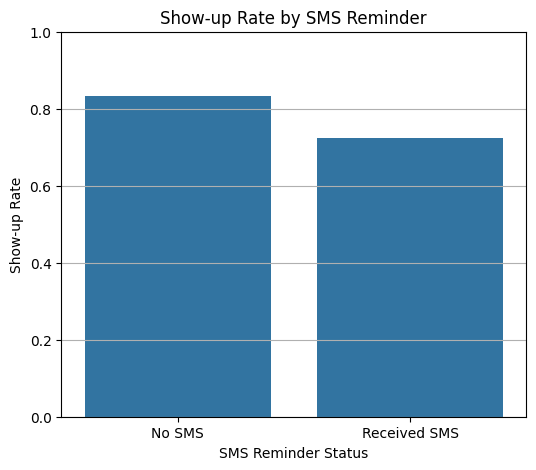

In [109]:
plt.figure(figsize=(6, 5))
sns.barplot(x=sms_summary.index, y=sms_summary["Show_up_Rate"])
plt.title("Show-up Rate by SMS Reminder")
plt.ylabel("Show-up Rate")
plt.xlabel("SMS Reminder Status")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [110]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 18, 30, 45, 60, 75, 100], 
                        labels=["0-18", "19-30", "31-45", "46-60", "61-75", "76+"])


In [111]:
age_group_summary = df.groupby("AgeGroup")["Showed_up"].agg(['count', 'sum'])
age_group_summary["Show_up_Rate"] = age_group_summary["sum"] / age_group_summary["count"]

C:\Users\Kiran\AppData\Local\Temp\ipykernel_1936\2005306529.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_summary = df.groupby("AgeGroup")["Showed_up"].agg(['count', 'sum'])


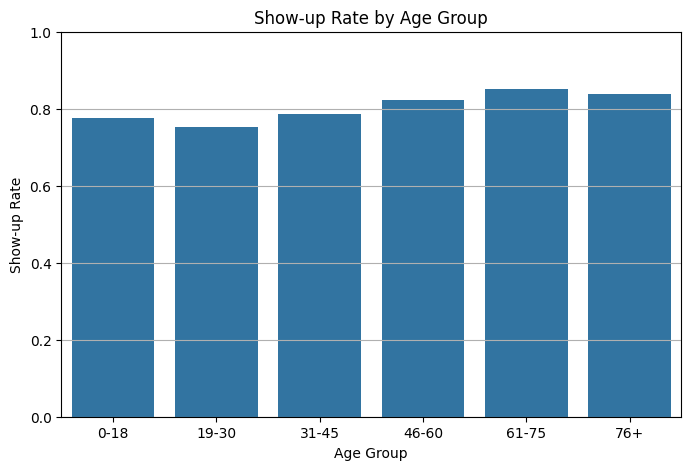

In [112]:
plt.figure(figsize=(8, 5))
sns.barplot(x=age_group_summary.index, y=age_group_summary["Show_up_Rate"])
plt.title("Show-up Rate by Age Group")
plt.ylabel("Show-up Rate")
plt.xlabel("Age Group")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

In [118]:
df=pd.read_csv("C:\\Users\\Kiran\\Downloads\\healthcare_noshows_appt.csv",
               encoding="unicode-escape")

In [119]:
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])
df["Weekday"] = df["AppointmentDay"].dt.day_name()

In [120]:
weekday_summary = df.groupby("Weekday")["Showed_up"].agg(['count', 'sum'])
weekday_summary["Show_up_Rate"] = weekday_summary["sum"] / weekday_summary["count"]

In [121]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = weekday_summary.reindex(weekday_order)

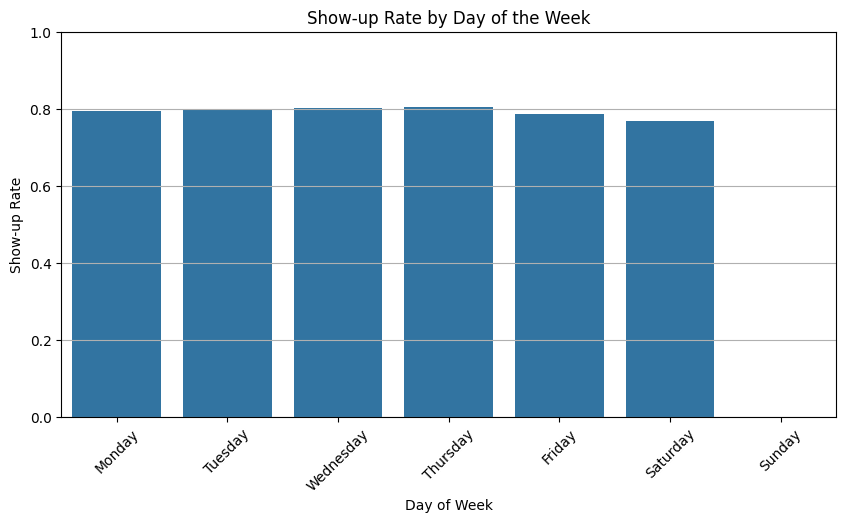

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_summary.index, y=weekday_summary["Show_up_Rate"])
plt.title("Show-up Rate by Day of the Week")
plt.ylabel("Show-up Rate")
plt.xlabel("Day of Week")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()
